Video for inspiration:
https://www.youtube.com/watch?v=ccIl0clxJpE


**Ideas for later**
- Sliders for alpha, beta, gamma, and delta?
- Monte Carlo Simulation (https://www.youtube.com/shorts/_eJVBmi4jwg)



![](wiki.png)
The Lotka–Volterra predator-prey model makes a number of assumptions about the environment and biology of the predator and prey populations:

1. The prey population finds ample food at all times.
2. The food supply of the predator population depends entirely on the size of the prey population.
3. The rate of change of population is proportional to its size.
4. During the process, the environment does not change in favour of one species, and genetic adaptation is inconsequential.
5. Predators have limitless appetite.
6. Both populations can be described by a single variable. This amounts to assuming that the populations do not have a spatial or age distribution that contributes to the dynamics.
From: https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations

In [6]:
import polars as pl
import numpy as np


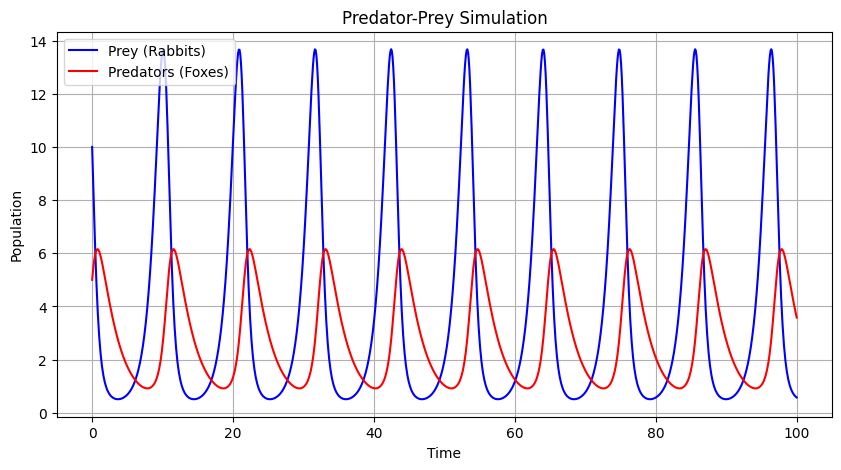

In [7]:
'''
This is a rough draft of printing out a MVP of a Predator-Prey model, but we just imported the ODE solver, which would be nice to know under the hood... 
which is explored in later blocks of code
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

#set up equation
def lotka_volterra(z, t, a, b, c, d):
    x, y = z
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

# Set parameters and initial conditions
# a: prey growth, b: predation rate, c: predator death, d: predator growth
params = (1.1, 0.4, 0.4, 0.1) 
initial_state = [10, 5]  # 10 rabbits, 5 foxes

# Create a time grid (0 to 100 units of time)
# np.linspace makes an array of evenly spaced numbers over a specified interval
t = np.linspace(0, 100, 1000)

# Solve the ODE
solution = odeint(lotka_volterra, initial_state, t, args=params)
#need to transpose bc odeint returns a 
prey, predators = solution.T

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(t, prey, label='Prey (Rabbits)', color='blue')
plt.plot(t, predators, label='Predators (Foxes)', color='red')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Predator-Prey Simulation')
plt.legend()
plt.grid(True)
plt.show()

As more rabbits are being eaten, and the foxes continue to grow, we see the prey decreasing, until it gets to a point where there's only so much prey that can be sustained. 

Text(0.5, 1.0, 'Phase Portrait')

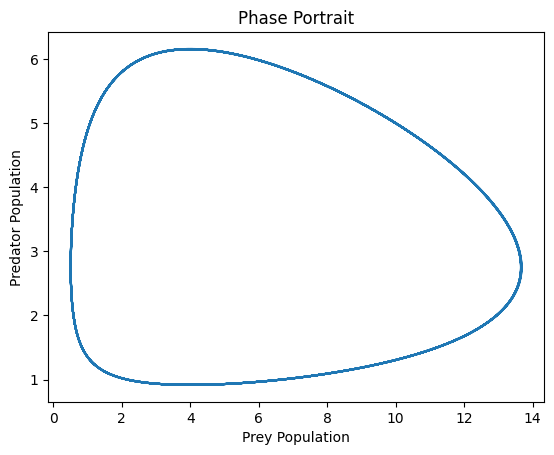

In [8]:
#this is a phase portrait, which shows that the system is fully contained, and the pred/prey runs in a constant cycle of growth and decline accordingly.
plt.plot(prey, predators)
plt.xlabel('Prey Population')
plt.ylabel('Predator Population')
plt.title('Phase Portrait')

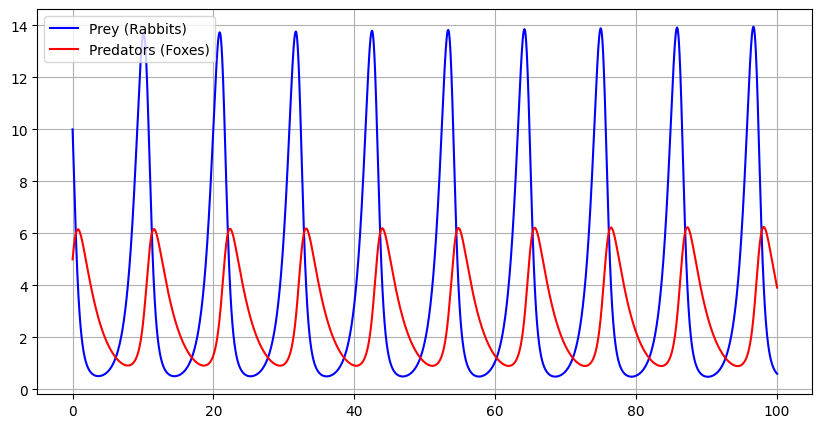

In [ ]:
#raw implementation with first order 
import numpy as np
import matplotlib.pyplot as plt

# Parameters (adjusted to match the visual scale of your image)
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.001  # Very small step to reduce numerical drift
t_final = 100
steps = int(t_final / dt)

prey = np.zeros(steps)
pred = np.zeros(steps)
t = np.linspace(0, t_final, steps)

# Initial conditions
prey[0] = 10
pred[0] = 5

#LV pred-prey equation implementation
#
for i in range(1, steps):
    # Forward Euler logic
    dxdt = a * prey[i-1] - b * prey[i-1] * pred[i-1]
    dydt = d * prey[i-1] * pred[i-1] - c * pred[i-1]
    
    prey[i] = prey[i-1] + (dxdt * dt)
    pred[i] = pred[i-1] + (dydt * dt)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t, prey, label='Prey (Rabbits)', color='blue')
plt.plot(t, pred, label='Predators (Foxes)', color='red')
plt.grid(True)
plt.legend()
plt.show()

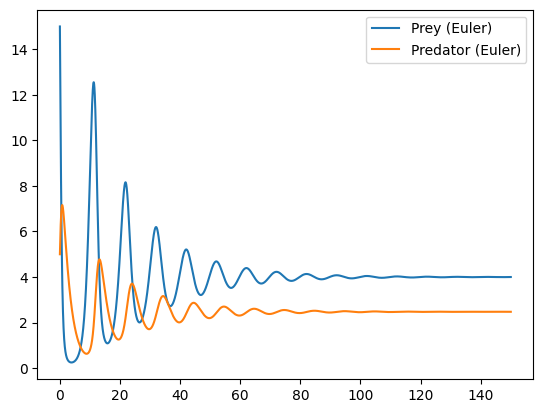

In [10]:
#raw implementation with carrying capacity (amount of rabbits can be limited)
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a, b, c, d, K = 1.1, 0.4, 0.4, 0.1, 40
dt = 0.01  # This is our 'tiny step' size
t_final = 150
steps = int(t_final / dt)

# Initialize arrays to hold our results
prey = np.zeros(steps)
pred = np.zeros(steps)
t = np.linspace(0, t_final, steps)

# Initial conditions
prey[0] = 15
pred[0] = 5

# The Simulation Loop (Euler's Method)
for i in range(1, steps):
    # 1. Calculate the rates of change (the slopes)
    dxdt = a * prey[i-1] * (1 - prey[i-1]/K) - b * prey[i-1] * pred[i-1]
    dydt = d * prey[i-1] * pred[i-1] - c * pred[i-1]
    
    # 2. Update the populations
    prey[i] = prey[i-1] + (dxdt * dt)
    pred[i] = pred[i-1] + (dydt * dt)

# Plotting
plt.plot(t, prey, label='Prey (Euler)')
plt.plot(t, pred, label='Predator (Euler)')
plt.legend()
plt.show()

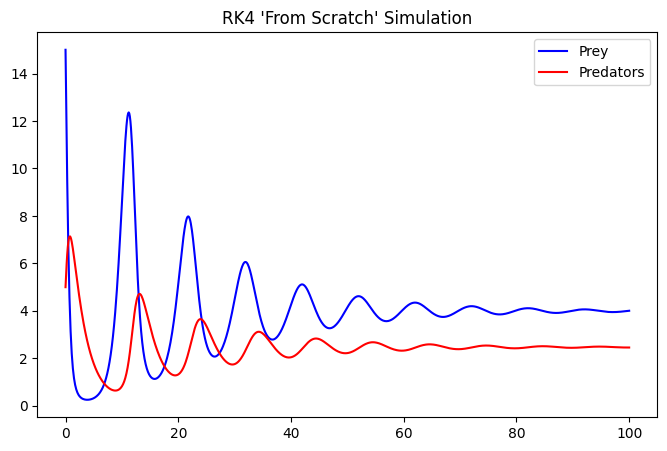

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Model and Parameters
def system_dynamics(z, a, b, c, d, K):
    x, y = z
    dxdt = a * x * (1 - x / K) - b * x * y
    dydt = d * x * y - c * y
    return np.array([dxdt, dydt])

a, b, c, d, K = 1.1, 0.4, 0.4, 0.1, 40
dt = 0.1
t_final = 100
steps = int(t_final / dt)

# 2. Initialize storage
results = np.zeros((steps, 2))
t = np.linspace(0, t_final, steps)
z = np.array([15.0, 5.0]) # Initial state [prey, pred]

# 3. The RK4 Loop
for i in range(steps):
    results[i] = z
    
    # Calculate the 4 trial steps
    k1 = system_dynamics(z, a, b, c, d, K)
    k2 = system_dynamics(z + (dt/2)*k1, a, b, c, d, K)
    k3 = system_dynamics(z + (dt/2)*k2, a, b, c, d, K)
    k4 = system_dynamics(z + dt*k3, a, b, c, d, K)
    
    # Combine them (weighted average) to update the state
    z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

prey, predators = results.T

# 4. Visualization
plt.figure(figsize=(8, 5))
plt.plot(t, prey, label='Prey', color='blue')
plt.plot(t, predators, label='Predators', color='red')
plt.title("RK4 'From Scratch' Simulation")
plt.legend()
plt.show()